# 超参数搜索结果热力图分析

本notebook用于分析 `hyperparam_search_forget05_7b_mlp` 实验的结果，通过热力图可视化不同 alpha-beta 组合下的评估指标。

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 设置图表样式
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

## 1. 加载数据

In [4]:
# 数据目录
base_dir = Path('/cnz/data/project/my-open-unlearning/saves/unlearn/hyperparam_search_forget05_phi_mlp_e5')

# 收集所有评估结果
results = []

for model_dir in sorted(base_dir.glob('model_a*_b*')):
    # 从文件夹名称提取 alpha 和 beta
    dir_name = model_dir.name
    parts = dir_name.replace('model_a', '').split('_b')
    alpha = float(parts[0])
    beta = float(parts[1])
    
    # 读取 evals 子目录中的 TOFU_SUMMARY.json
    summary_file = model_dir / 'evals' / 'TOFU_SUMMARY.json'
    if summary_file.exists():
        with open(summary_file, 'r') as f:
            metrics = json.load(f)
        
        # 添加 alpha 和 beta
        metrics['alpha'] = alpha
        metrics['beta'] = beta
        results.append(metrics)
    else:
        print(f"警告: 找不到评估文件 {summary_file}")

# 转换为 DataFrame
df = pd.DataFrame(results)

# 按 alpha 和 beta 排序
df = df.sort_values(['alpha', 'beta']).reset_index(drop=True)

print(f"加载了 {len(df)} 组实验结果")
print(f"\nAlpha 范围: {df['alpha'].min()} - {df['alpha'].max()}")
print(f"Beta 范围: {df['beta'].min()} - {df['beta'].max()}")
print(f"\n评估指标: {[col for col in df.columns if col not in ['alpha', 'beta']]}")

加载了 9 组实验结果

Alpha 范围: 0.8 - 1.2
Beta 范围: 0.8 - 1.2

评估指标: ['exact_memorization', 'extraction_strength', 'extraction_strength_retain', 'forget_Q_A_Prob', 'forget_Q_A_ROUGE', 'forget_quality', 'forget_truth_ratio', 'model_utility', 'privleak', 'retain_Q_A_Prob', 'retain_Q_A_ROUGE']


In [5]:
# 查看前几行数据
df.head()

,exact_memorization,extraction_strength,extraction_strength_retain,forget_Q_A_Prob,forget_Q_A_ROUGE,forget_quality,forget_truth_ratio,model_utility,privleak,retain_Q_A_Prob,retain_Q_A_ROUGE,alpha,beta
0,0.710339,0.087172,0.639223,0.338259,0.425781,0.087838,0.575843,0.413050,-80.677291,0.863555,0.647557,0.8,0.8
1,0.676772,0.076010,0.515442,0.289569,0.416796,0.087838,0.576425,0.397181,-77.501532,0.815862,0.606292,0.8,1.0
2,0.652132,0.067672,0.420553,0.237691,0.407636,0.142075,0.578789,0.371301,-72.789611,0.746353,0.564709,0.8,1.2
3,0.626178,0.067803,0.583790,0.202286,0.406277,0.923837,0.609050,0.408019,-47.877720,0.838619,0.620993,1.0,0.8
4,0.619556,0.063815,0.499500,0.187356,0.399896,0.923837,0.603113,0.403269,-48.954183,0.808648,0.604771,1.0,1.0


## 2. 创建热力图函数

In [6]:
def create_heatmap(df, metric_name, figsize=(10, 8), cmap='RdYlGn', annot=True, fmt='.3f'):
    """
    创建单个指标的热力图
    
    参数:
    - df: DataFrame，包含 alpha, beta 和各评估指标
    - metric_name: 要可视化的指标名称
    - figsize: 图形大小
    - cmap: 颜色映射 ('RdYlGn', 'viridis', 'coolwarm' 等)
    - annot: 是否在单元格中显示数值
    - fmt: 数值格式
    """
    # 创建数据透视表
    pivot_data = df.pivot(index='alpha', columns='beta', values=metric_name)
    
    # 创建图形
    plt.figure(figsize=figsize)
    
    # 绘制热力图
    sns.heatmap(pivot_data, annot=annot, fmt=fmt, cmap=cmap, 
                cbar_kws={'label': metric_name},
                linewidths=0.5, linecolor='gray')
    
    plt.title(f'{metric_name} vs Alpha and Beta', fontsize=14, pad=20)
    plt.xlabel('Beta', fontsize=12)
    plt.ylabel('Alpha', fontsize=12)
    
    # 调整布局
    plt.tight_layout()
    
    return plt.gcf()

## 3. 可视化关键指标

### 3.1 Forget Quality (遗忘质量) - 越高越好

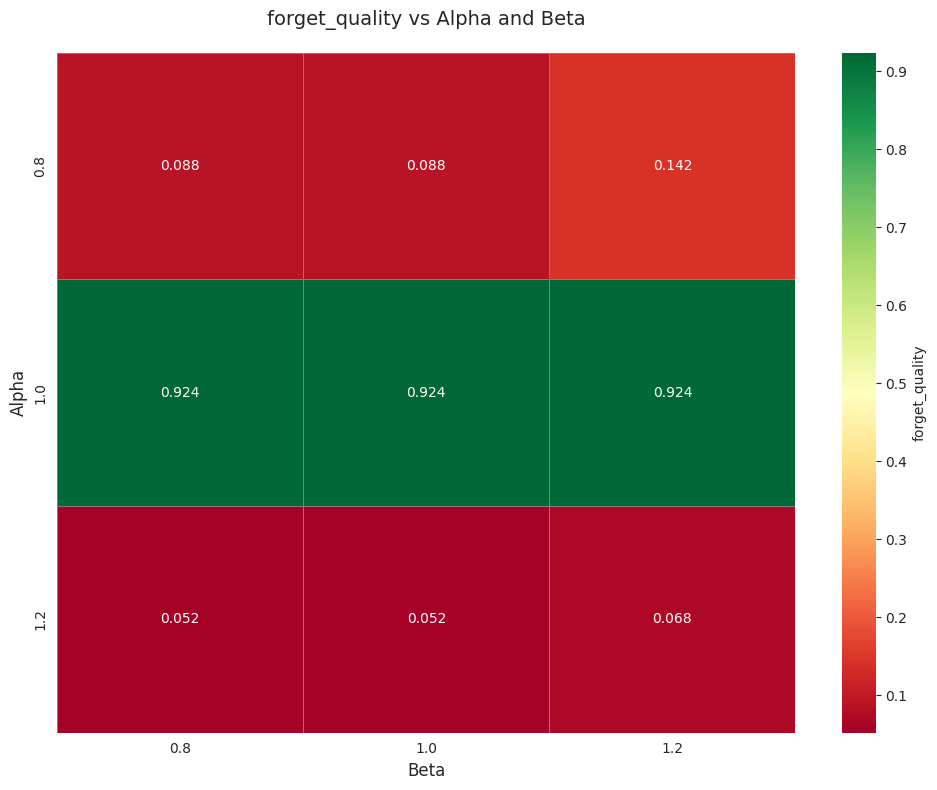

In [7]:
create_heatmap(df, 'forget_quality', cmap='RdYlGn')
plt.show()

### 3.2 Model Utility (模型效用) - 越高越好

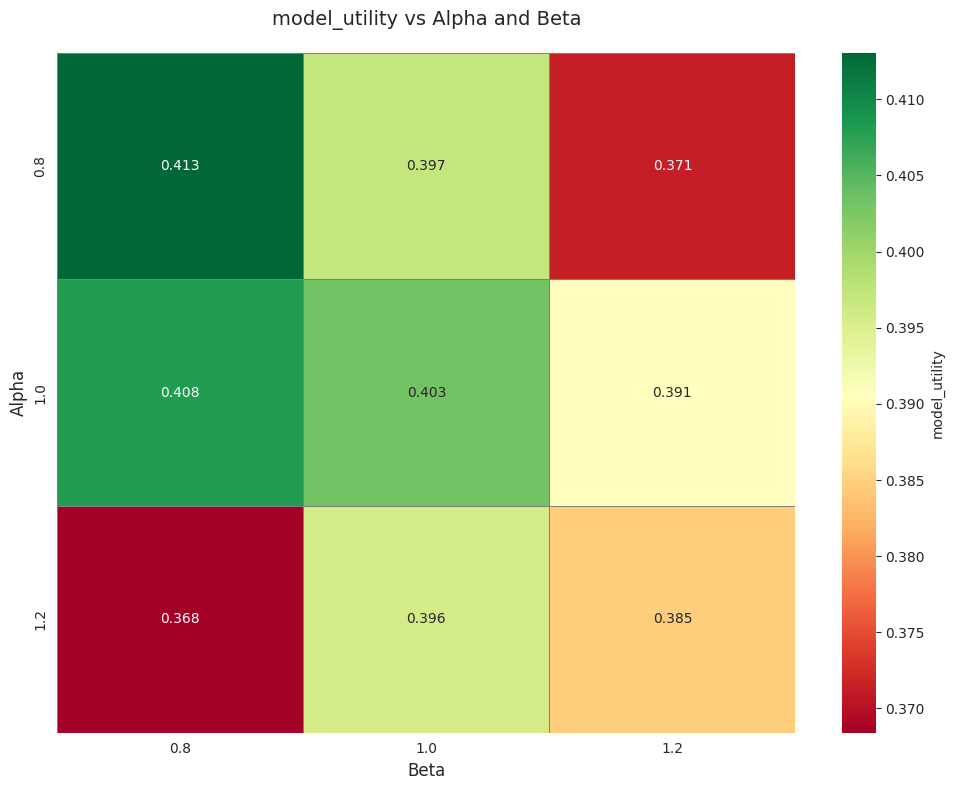

In [8]:
create_heatmap(df, 'model_utility', cmap='RdYlGn')
plt.show()

### 3.3 综合得分 (Forget Quality + Model Utility)

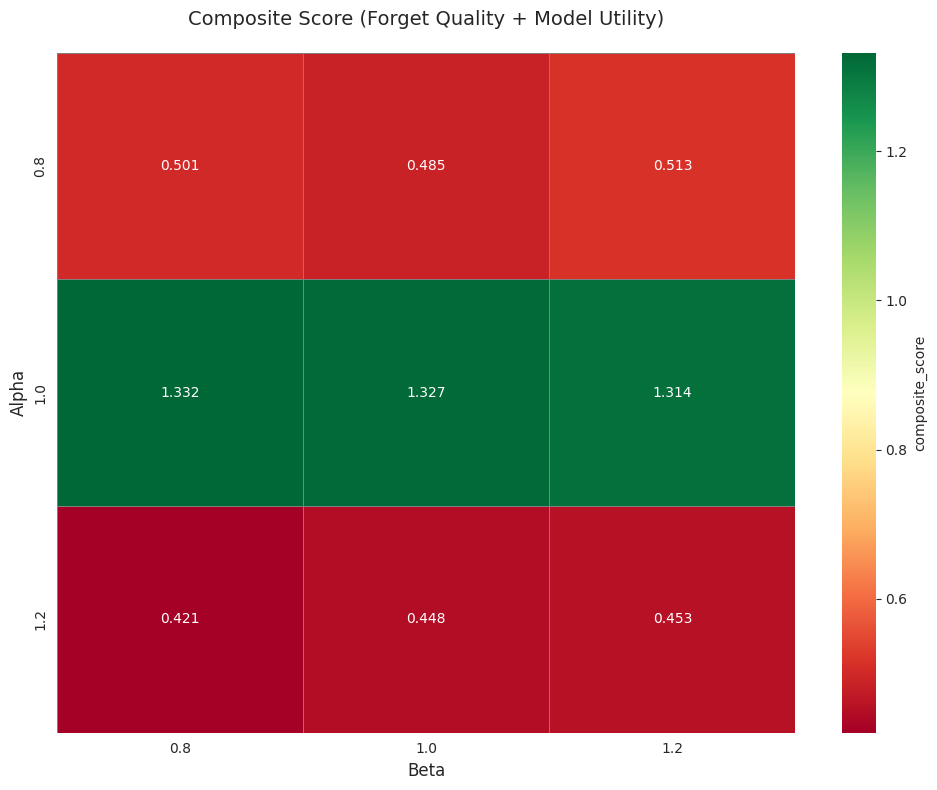

In [9]:
# 计算综合得分：高遗忘质量（好）+ 高模型效用（好）
df['composite_score'] = df['forget_quality'] + df['model_utility']

create_heatmap(df, 'composite_score', cmap='RdYlGn')
plt.title('Composite Score (Forget Quality + Model Utility)', fontsize=14, pad=20)
plt.show()

### 3.4 Extraction Strength (ES) - 越低越好

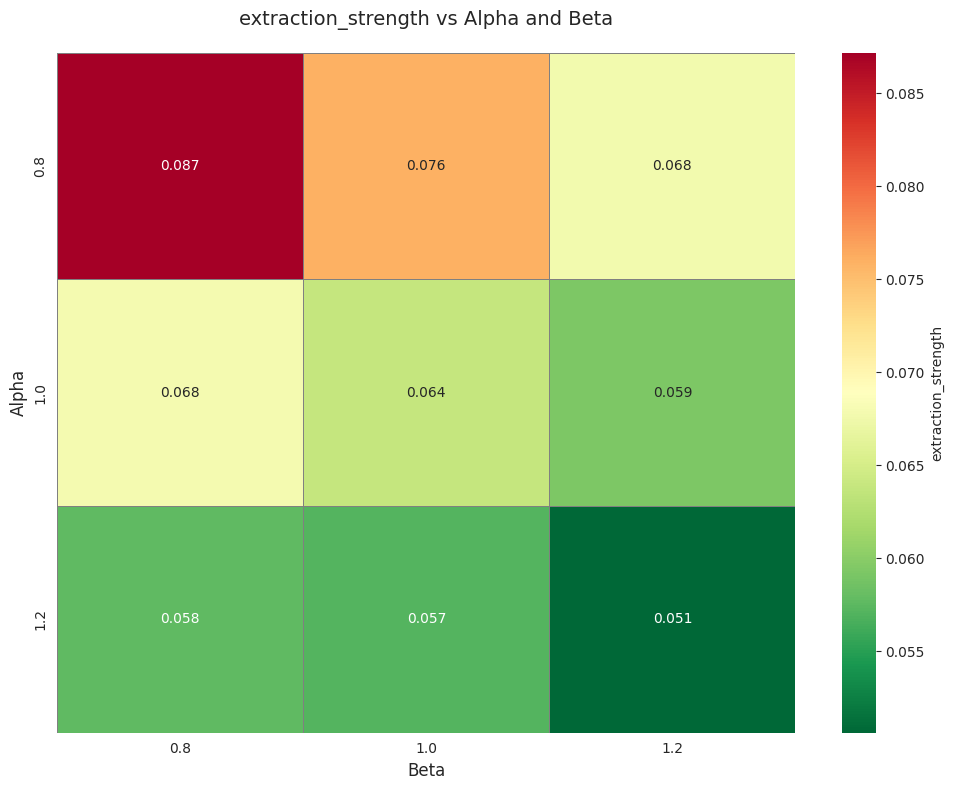

In [10]:
create_heatmap(df, 'extraction_strength', cmap='RdYlGn_r')
plt.show()

### 3.5 Extraction Strength Retain (ES RE) - 越高越好

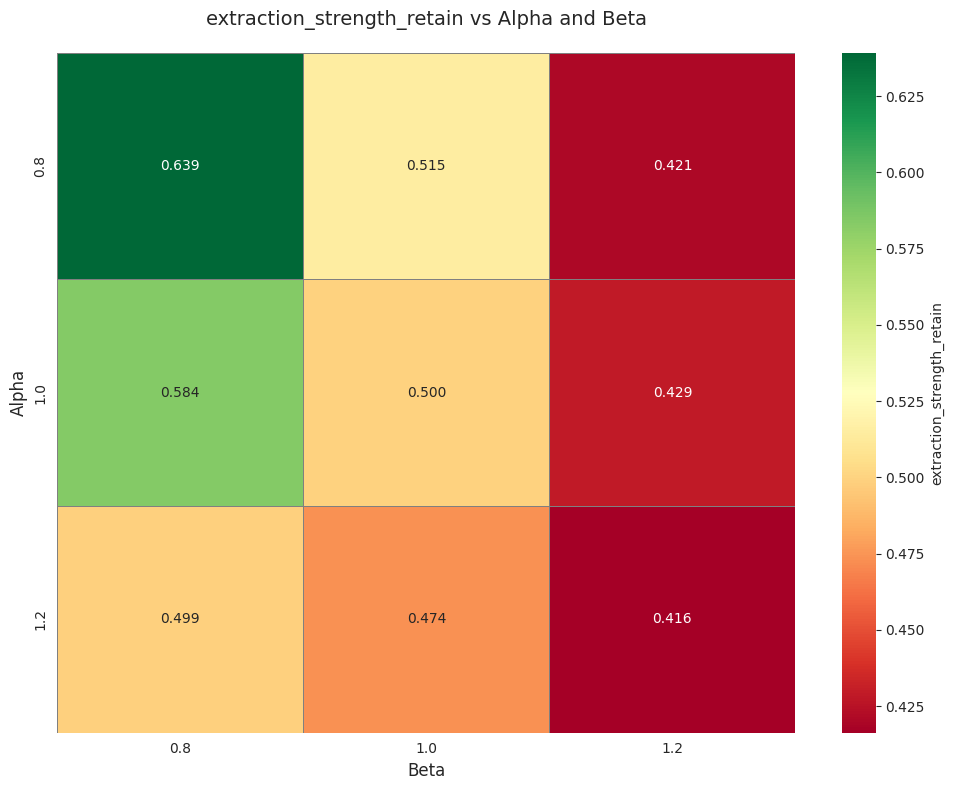

In [11]:
create_heatmap(df, 'extraction_strength_retain', cmap='RdYlGn')
plt.show()

### 3.6 基于 ES 和 ES RE 的综合评分

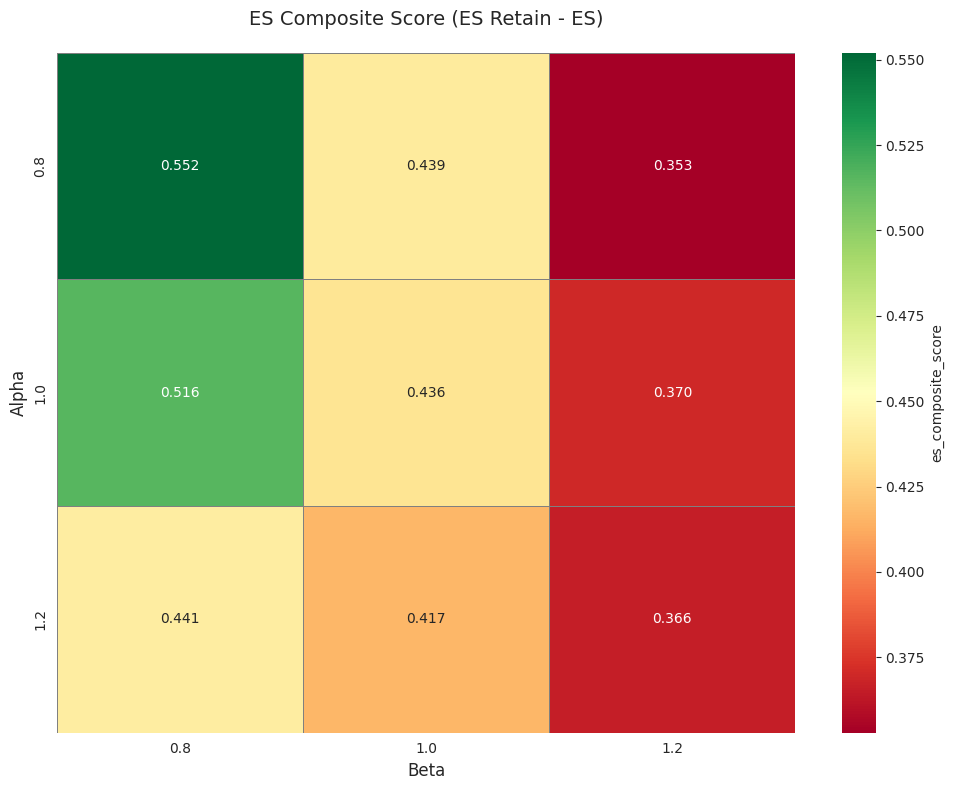

In [12]:
# 计算基于 ES 的综合得分：高 ES RE（好）- 低 ES（好）
df['es_composite_score'] = df['extraction_strength_retain'] - df['extraction_strength']

create_heatmap(df, 'es_composite_score', cmap='RdYlGn')
plt.title('ES Composite Score (ES Retain - ES)', fontsize=14, pad=20)
plt.show()

## 4. 所有指标的热力图

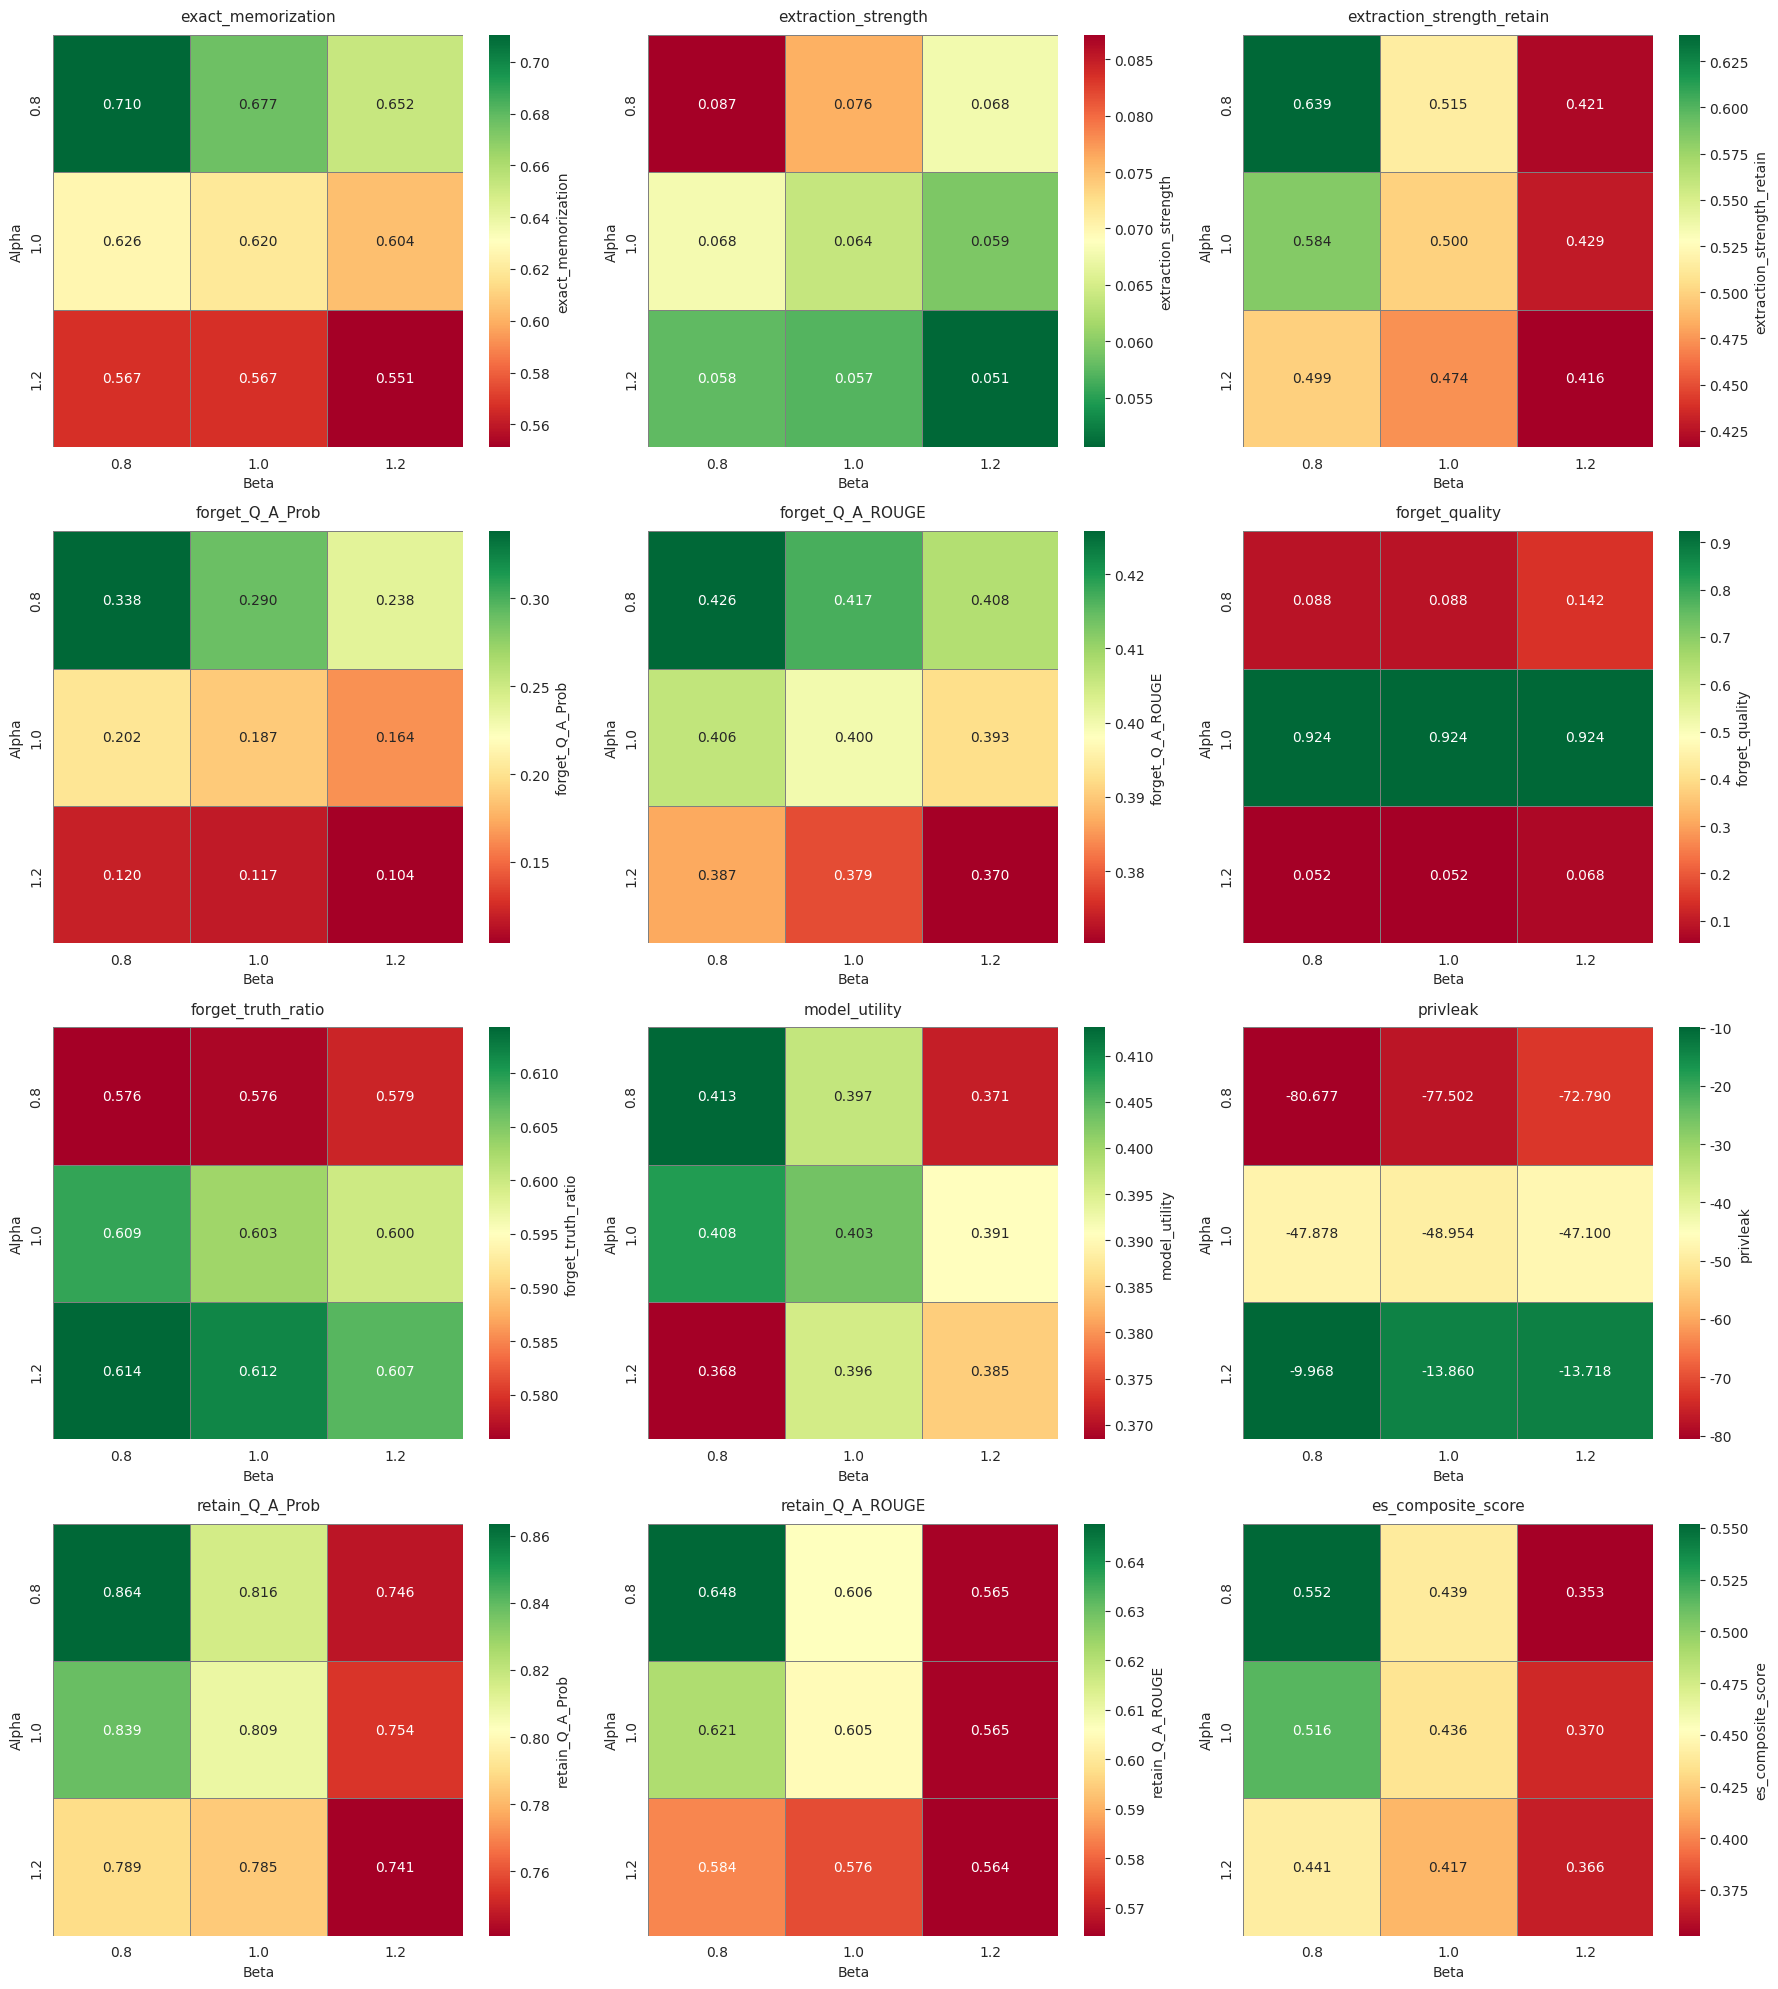

In [13]:
# 获取所有评估指标
metrics = [col for col in df.columns if col not in ['alpha', 'beta', 'composite_score']]

# 为每个指标创建热力图
n_metrics = len(metrics)
n_cols = 3
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten() if n_metrics > 1 else [axes]

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # 创建数据透视表
    pivot_data = df.pivot(index='alpha', columns='beta', values=metric)
    
    # 选择合适的颜色映射
    # extraction_strength 越低越好，使用反向色图
    # 其他指标（包括 forget_quality）都是越高越好
    if metric == 'extraction_strength':
        cmap = 'RdYlGn_r'
    else:
        cmap = 'RdYlGn'
    
    # 绘制热力图
    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': metric},
                linewidths=0.5, linecolor='gray')
    
    ax.set_title(metric, fontsize=11, pad=10)
    ax.set_xlabel('Beta', fontsize=10)
    ax.set_ylabel('Alpha', fontsize=10)

# 隐藏多余的子图
for idx in range(n_metrics, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 5. 找出最优参数组合

In [14]:
# 基于不同标准找出最优参数
print("="*60)
print("最优参数组合分析")
print("="*60)

# 1. 最高遗忘质量
best_forget = df.loc[df['forget_quality'].idxmax()]
print(f"\n1. 最高遗忘质量:")
print(f"   Alpha={best_forget['alpha']}, Beta={best_forget['beta']}")
print(f"   Forget Quality: {best_forget['forget_quality']:.4f}")
print(f"   Model Utility: {best_forget['model_utility']:.4f}")

# 2. 最高模型效用
best_utility = df.loc[df['model_utility'].idxmax()]
print(f"\n2. 最高模型效用:")
print(f"   Alpha={best_utility['alpha']}, Beta={best_utility['beta']}")
print(f"   Forget Quality: {best_utility['forget_quality']:.4f}")
print(f"   Model Utility: {best_utility['model_utility']:.4f}")

# 3. 最佳综合得分
best_composite = df.loc[df['composite_score'].idxmax()]
print(f"\n3. 最佳综合得分 (Forget Quality + Model Utility):")
print(f"   Alpha={best_composite['alpha']}, Beta={best_composite['beta']}")
print(f"   Forget Quality: {best_composite['forget_quality']:.4f}")
print(f"   Model Utility: {best_composite['model_utility']:.4f}")
print(f"   Composite Score: {best_composite['composite_score']:.4f}")

# 4. 平衡方案：模型效用 > 0.6 且遗忘质量最高
balanced = df[df['model_utility'] > 0.6]
if len(balanced) > 0:
    best_balanced = balanced.loc[balanced['forget_quality'].idxmax()]
    print(f"\n4. 平衡方案 (Model Utility > 0.6 且遗忘质量最高):")
    print(f"   Alpha={best_balanced['alpha']}, Beta={best_balanced['beta']}")
    print(f"   Forget Quality: {best_balanced['forget_quality']:.4f}")
    print(f"   Model Utility: {best_balanced['model_utility']:.4f}")

# 5. 最低 Extraction Strength (ES)
best_es = df.loc[df['extraction_strength'].idxmin()]
print(f"\n5. 最低 Extraction Strength (ES ↓):")
print(f"   Alpha={best_es['alpha']}, Beta={best_es['beta']}")
print(f"   ES: {best_es['extraction_strength']:.4f}")
print(f"   ES Retain: {best_es['extraction_strength_retain']:.4f}")
print(f"   ES Composite: {best_es['es_composite_score']:.4f}")

# 6. 最高 Extraction Strength Retain (ES RE)
best_es_retain = df.loc[df['extraction_strength_retain'].idxmax()]
print(f"\n6. 最高 Extraction Strength Retain (ES RE ↑):")
print(f"   Alpha={best_es_retain['alpha']}, Beta={best_es_retain['beta']}")
print(f"   ES: {best_es_retain['extraction_strength']:.4f}")
print(f"   ES Retain: {best_es_retain['extraction_strength_retain']:.4f}")
print(f"   ES Composite: {best_es_retain['es_composite_score']:.4f}")

# 7. 最佳 ES 综合得分
best_es_composite = df.loc[df['es_composite_score'].idxmax()]
print(f"\n7. 最佳 ES 综合得分 (ES Retain - ES):")
print(f"   Alpha={best_es_composite['alpha']}, Beta={best_es_composite['beta']}")
print(f"   ES: {best_es_composite['extraction_strength']:.4f}")
print(f"   ES Retain: {best_es_composite['extraction_strength_retain']:.4f}")
print(f"   ES Composite: {best_es_composite['es_composite_score']:.4f}")

# 8. 平衡方案：ES Retain > 0.8 且 ES 最低
es_balanced = df[df['extraction_strength_retain'] > 0.8]
if len(es_balanced) > 0:
    best_es_balanced = es_balanced.loc[es_balanced['extraction_strength'].idxmin()]
    print(f"\n8. ES 平衡方案 (ES Retain > 0.8 且 ES 最低):")
    print(f"   Alpha={best_es_balanced['alpha']}, Beta={best_es_balanced['beta']}")
    print(f"   ES: {best_es_balanced['extraction_strength']:.4f}")
    print(f"   ES Retain: {best_es_balanced['extraction_strength_retain']:.4f}")
    print(f"   ES Composite: {best_es_balanced['es_composite_score']:.4f}")

print("\n" + "="*60)

最优参数组合分析

1. 最高遗忘质量:
   Alpha=1.0, Beta=0.8
   Forget Quality: 0.9238
   Model Utility: 0.4080

2. 最高模型效用:
   Alpha=0.8, Beta=0.8
   Forget Quality: 0.0878
   Model Utility: 0.4131

3. 最佳综合得分 (Forget Quality + Model Utility):
   Alpha=1.0, Beta=0.8
   Forget Quality: 0.9238
   Model Utility: 0.4080
   Composite Score: 1.3319

5. 最低 Extraction Strength (ES ↓):
   Alpha=1.2, Beta=1.2
   ES: 0.0506
   ES Retain: 0.4163
   ES Composite: 0.3657

6. 最高 Extraction Strength Retain (ES RE ↑):
   Alpha=0.8, Beta=0.8
   ES: 0.0872
   ES Retain: 0.6392
   ES Composite: 0.5521

7. 最佳 ES 综合得分 (ES Retain - ES):
   Alpha=0.8, Beta=0.8
   ES: 0.0872
   ES Retain: 0.6392
   ES Composite: 0.5521



## 6. 参数敏感性分析

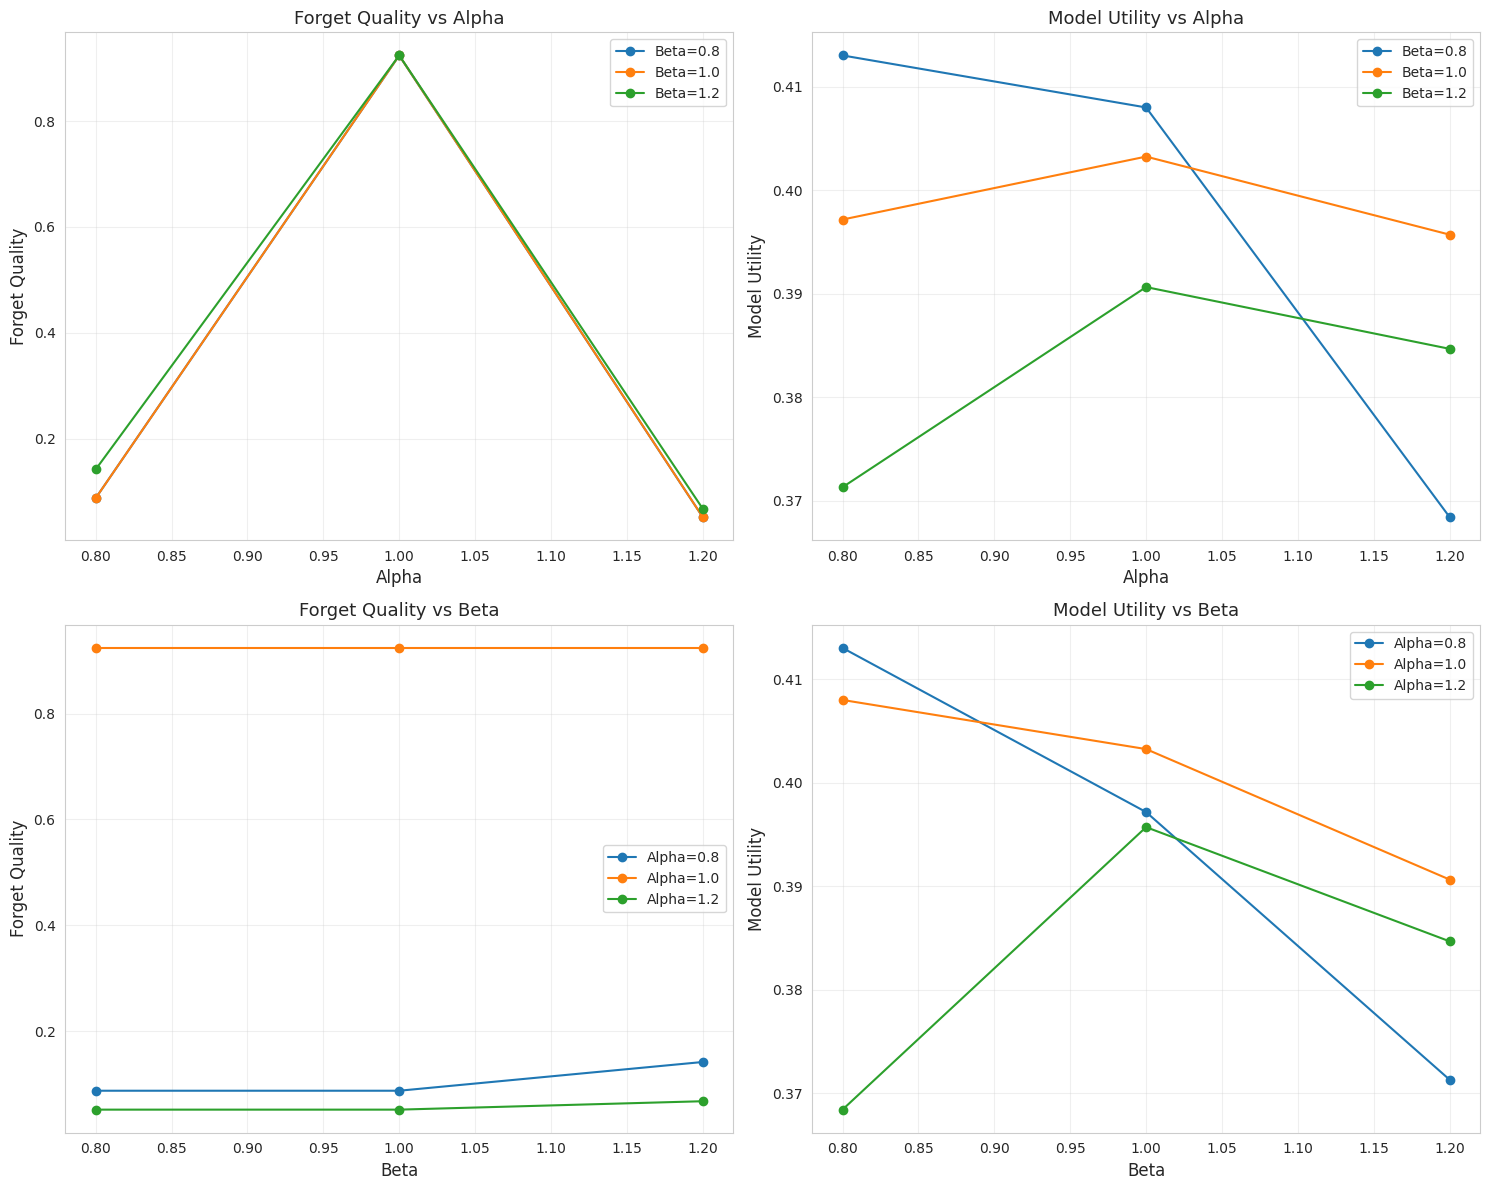

In [15]:
# 分析 alpha 和 beta 对关键指标的影响
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Forget Quality vs Alpha (不同 Beta 的曲线)
ax = axes[0, 0]
for beta in sorted(df['beta'].unique()):
    data = df[df['beta'] == beta]
    ax.plot(data['alpha'], data['forget_quality'], marker='o', label=f'Beta={beta}')
ax.set_xlabel('Alpha', fontsize=12)
ax.set_ylabel('Forget Quality', fontsize=12)
ax.set_title('Forget Quality vs Alpha', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Model Utility vs Alpha
ax = axes[0, 1]
for beta in sorted(df['beta'].unique()):
    data = df[df['beta'] == beta]
    ax.plot(data['alpha'], data['model_utility'], marker='o', label=f'Beta={beta}')
ax.set_xlabel('Alpha', fontsize=12)
ax.set_ylabel('Model Utility', fontsize=12)
ax.set_title('Model Utility vs Alpha', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Forget Quality vs Beta (不同 Alpha 的曲线)
ax = axes[1, 0]
for alpha in sorted(df['alpha'].unique()):
    data = df[df['alpha'] == alpha]
    ax.plot(data['beta'], data['forget_quality'], marker='o', label=f'Alpha={alpha}')
ax.set_xlabel('Beta', fontsize=12)
ax.set_ylabel('Forget Quality', fontsize=12)
ax.set_title('Forget Quality vs Beta', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Model Utility vs Beta
ax = axes[1, 1]
for alpha in sorted(df['alpha'].unique()):
    data = df[df['alpha'] == alpha]
    ax.plot(data['beta'], data['model_utility'], marker='o', label=f'Alpha={alpha}')
ax.set_xlabel('Beta', fontsize=12)
ax.set_ylabel('Model Utility', fontsize=12)
ax.set_title('Model Utility vs Beta', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.1 ES 和 ES Retain 参数敏感性分析

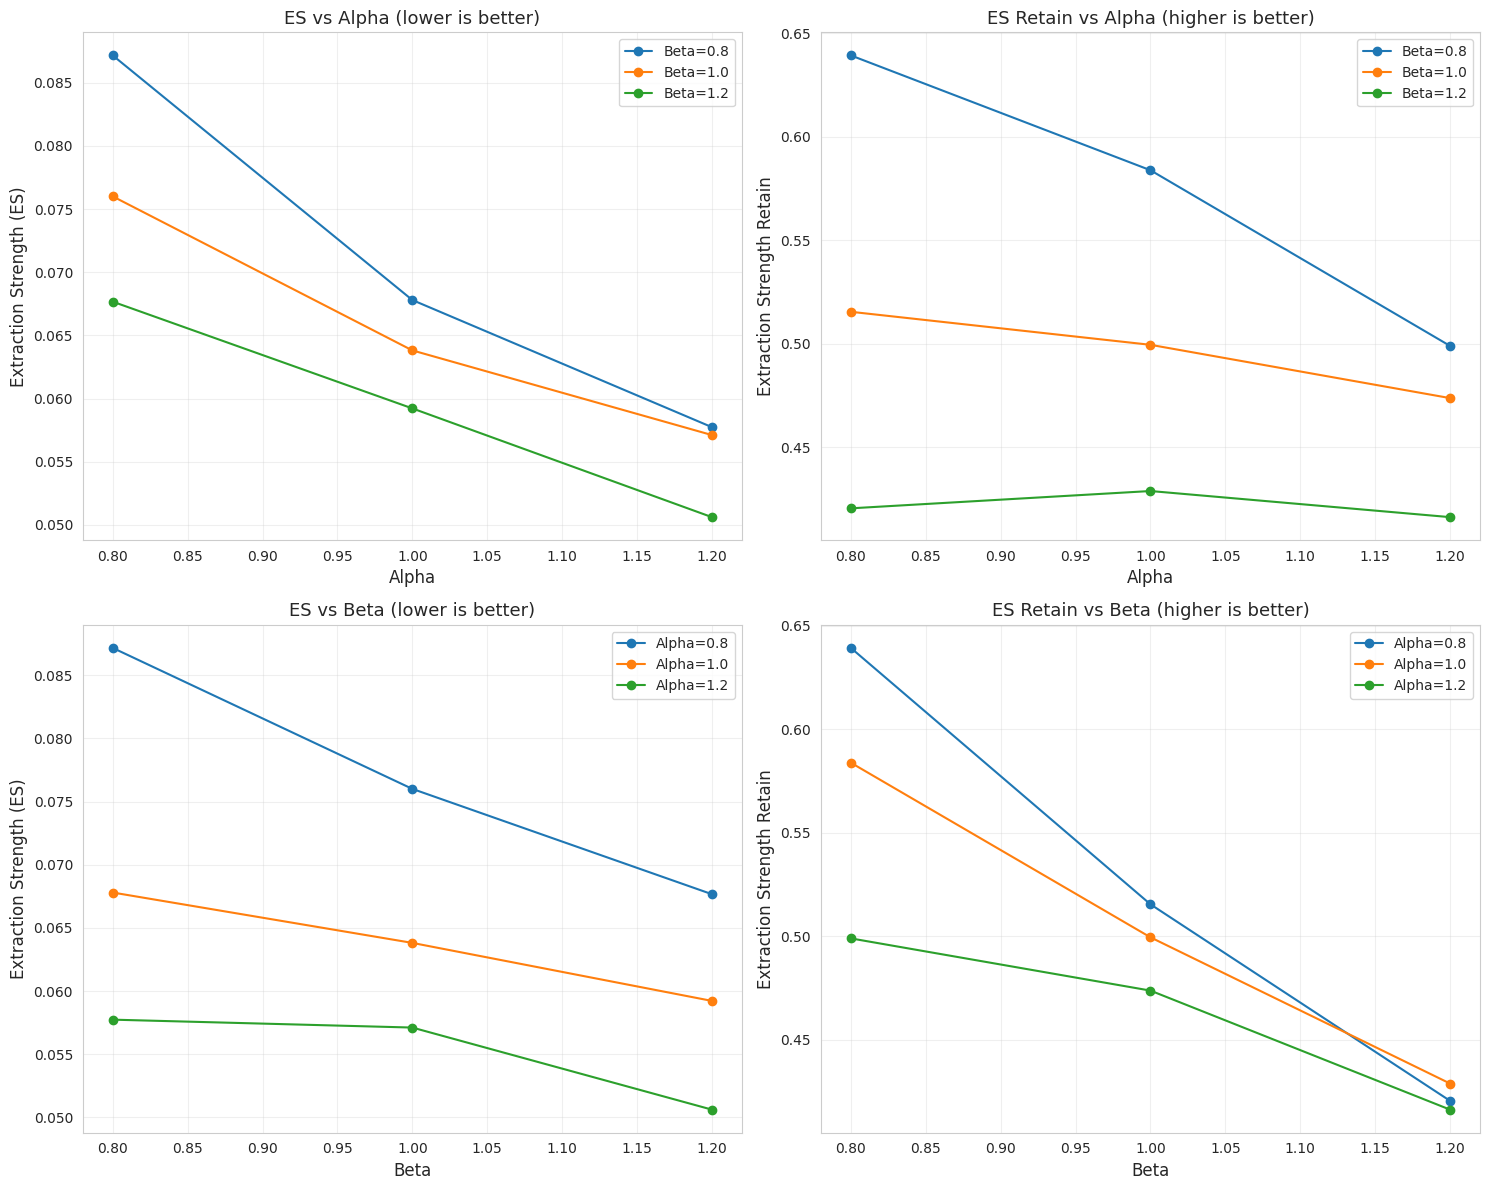

In [16]:
# 分析 alpha 和 beta 对 ES 指标的影响
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. ES vs Alpha (不同 Beta 的曲线)
ax = axes[0, 0]
for beta in sorted(df['beta'].unique()):
    data = df[df['beta'] == beta]
    ax.plot(data['alpha'], data['extraction_strength'], marker='o', label=f'Beta={beta}')
ax.set_xlabel('Alpha', fontsize=12)
ax.set_ylabel('Extraction Strength (ES)', fontsize=12)
ax.set_title('ES vs Alpha (lower is better)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# 2. ES Retain vs Alpha
ax = axes[0, 1]
for beta in sorted(df['beta'].unique()):
    data = df[df['beta'] == beta]
    ax.plot(data['alpha'], data['extraction_strength_retain'], marker='o', label=f'Beta={beta}')
ax.set_xlabel('Alpha', fontsize=12)
ax.set_ylabel('Extraction Strength Retain', fontsize=12)
ax.set_title('ES Retain vs Alpha (higher is better)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# 3. ES vs Beta (不同 Alpha 的曲线)
ax = axes[1, 0]
for alpha in sorted(df['alpha'].unique()):
    data = df[df['alpha'] == alpha]
    ax.plot(data['beta'], data['extraction_strength'], marker='o', label=f'Alpha={alpha}')
ax.set_xlabel('Beta', fontsize=12)
ax.set_ylabel('Extraction Strength (ES)', fontsize=12)
ax.set_title('ES vs Beta (lower is better)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# 4. ES Retain vs Beta
ax = axes[1, 1]
for alpha in sorted(df['alpha'].unique()):
    data = df[df['alpha'] == alpha]
    ax.plot(data['beta'], data['extraction_strength_retain'], marker='o', label=f'Alpha={alpha}')
ax.set_xlabel('Beta', fontsize=12)
ax.set_ylabel('Extraction Strength Retain', fontsize=12)
ax.set_title('ES Retain vs Beta (higher is better)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 散点图：Forget Quality vs Model Utility

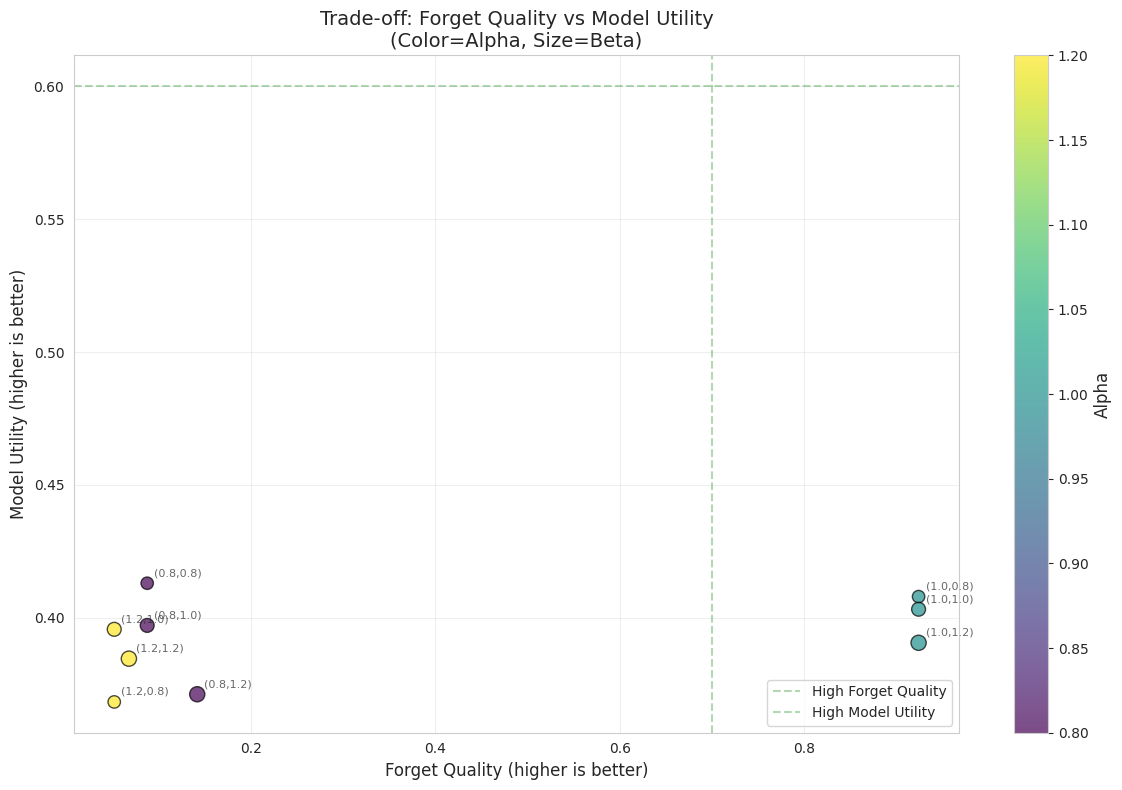

In [17]:
# 创建散点图，颜色表示 alpha，大小表示 beta
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(df['forget_quality'], df['model_utility'], 
                     c=df['alpha'], s=df['beta']*100, 
                     cmap='viridis', alpha=0.7, edgecolors='black', linewidth=1)

# 为每个点添加标签
for idx, row in df.iterrows():
    ax.annotate(f"({row['alpha']:.1f},{row['beta']:.1f})", 
                (row['forget_quality'], row['model_utility']),
                fontsize=8, alpha=0.7, xytext=(5, 5), 
                textcoords='offset points')

# 添加颜色条
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Alpha', fontsize=12)

# 添加理想区域标注（高遗忘质量，高模型效用）
ax.axvline(x=0.7, color='green', linestyle='--', alpha=0.3, label='High Forget Quality')
ax.axhline(y=0.6, color='green', linestyle='--', alpha=0.3, label='High Model Utility')

ax.set_xlabel('Forget Quality (higher is better)', fontsize=12)
ax.set_ylabel('Model Utility (higher is better)', fontsize=12)
ax.set_title('Trade-off: Forget Quality vs Model Utility\n(Color=Alpha, Size=Beta)', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.1 散点图：ES vs ES Retain

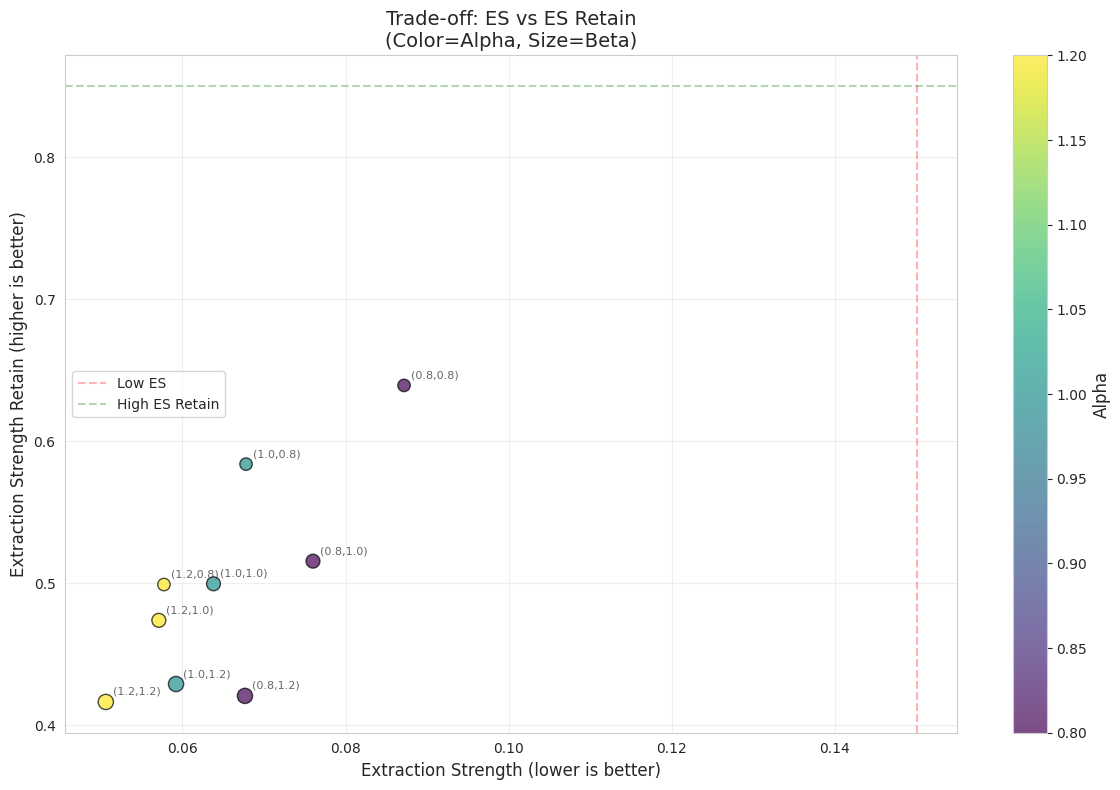

In [18]:
# 创建散点图，颜色表示 alpha，大小表示 beta
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(df['extraction_strength'], df['extraction_strength_retain'], 
                     c=df['alpha'], s=df['beta']*100, 
                     cmap='viridis', alpha=0.7, edgecolors='black', linewidth=1)

# 为每个点添加标签
for idx, row in df.iterrows():
    ax.annotate(f"({row['alpha']:.1f},{row['beta']:.1f})", 
                (row['extraction_strength'], row['extraction_strength_retain']),
                fontsize=8, alpha=0.7, xytext=(5, 5), 
                textcoords='offset points')

# 添加颜色条
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Alpha', fontsize=12)

# 添加理想区域标注（低 ES，高 ES Retain）
ax.axvline(x=0.15, color='red', linestyle='--', alpha=0.3, label='Low ES')
ax.axhline(y=0.85, color='green', linestyle='--', alpha=0.3, label='High ES Retain')

ax.set_xlabel('Extraction Strength (lower is better)', fontsize=12)
ax.set_ylabel('Extraction Strength Retain (higher is better)', fontsize=12)
ax.set_title('Trade-off: ES vs ES Retain\n(Color=Alpha, Size=Beta)', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 导出结果表格

In [19]:
# 按综合得分排序
df_sorted = df.sort_values('composite_score', ascending=False)

# 选择关键列
key_columns = ['alpha', 'beta', 'forget_quality', 'model_utility', 'composite_score', 
               'extraction_strength', 'extraction_strength_retain', 'es_composite_score',
               'retain_Q_A_Prob', 'forget_Q_A_Prob', 'exact_memorization']

# 显示前10个最佳配置（按综合得分）
print("Top 10 最佳参数配置 (按综合得分排序):\n")
print(df_sorted[key_columns].head(10).to_string(index=False))

# 显示前10个最佳配置（按 ES 综合得分）
print("\n" + "="*80)
print("\nTop 10 最佳参数配置 (按 ES 综合得分排序):\n")
df_sorted_es = df.sort_values('es_composite_score', ascending=False)
print(df_sorted_es[key_columns].head(10).to_string(index=False))

# 导出完整结果
output_file = base_dir / 'analysis_results.csv'
df_sorted.to_csv(output_file, index=False)
print(f"\n完整结果已保存到: {output_file}")

Top 10 最佳参数配置 (按综合得分排序):

 alpha  beta  forget_quality  model_utility  composite_score  extraction_strength  extraction_strength_retain  es_composite_score  retain_Q_A_Prob  forget_Q_A_Prob  exact_memorization
   1.0   0.8        0.923837       0.408019         1.331857             0.067803                    0.583790            0.515987         0.838619         0.202286            0.626178
   1.0   1.0        0.923837       0.403269         1.327106             0.063815                    0.499500            0.435685         0.808648         0.187356            0.619556
   1.0   1.2        0.923837       0.390652         1.314490             0.059222                    0.428908            0.369686         0.753786         0.163947            0.604191
   0.8   1.2        0.142075       0.371301         0.513375             0.067672                    0.420553            0.352881         0.746353         0.237691            0.652132
   0.8   0.8        0.087838       0.413050         0.

## 9. 统计摘要

In [20]:
# 显示所有指标的统计摘要
print("所有评估指标的统计摘要:\n")
print(df.describe().T.round(4))

所有评估指标的统计摘要:

                            count     mean      std      min      25%  \
exact_memorization            9.0   0.6194   0.0536   0.5513   0.5672   
extraction_strength           9.0   0.0652   0.0111   0.0506   0.0577   
extraction_strength_retain    9.0   0.4974   0.0755   0.4163   0.4289   
forget_Q_A_Prob               9.0   0.1956   0.0809   0.1037   0.1200   
forget_Q_A_ROUGE              9.0   0.3983   0.0180   0.3703   0.3866   
forget_quality                9.0   0.3624   0.4219   0.0521   0.0680   
forget_truth_ratio            9.0   0.5974   0.0159   0.5758   0.5788   
model_utility                 9.0   0.3925   0.0154   0.3684   0.3847   
privleak                      9.0 -45.8274  28.0605 -80.6773 -72.7896   
retain_Q_A_Prob               9.0   0.7935   0.0423   0.7408   0.7538   
retain_Q_A_ROUGE              9.0   0.5927   0.0292   0.5644   0.5650   
alpha                         9.0   1.0000   0.1732   0.8000   0.8000   
beta                          9.0   1